# Two contrasts, one ratio, and no bias field

[`01_build.ipynb`](01_build.ipynb) wrote one `.seq` file containing two contrasts, distinguished
only by a `SET` label. This notebook reads that label **back out of the file**, splits the data
by it, and combines the two images:

$$\mathrm{UNI} = \frac{\mathrm{Re}\left(S_1 \, S_2^{*}\right)}{|S_1|^2 + |S_2|^2}$$

Bounded on $[-0.5, 0.5]$, and the reason MP2RAGE exists: the receive field and the proton density
appear in **both** images and cancel in the ratio, leaving something close to a pure T1 contrast
with no shading.

Reading `SET` back rather than reconstructing the ordering is also what makes the label
load-bearing instead of decorative — a mislabelled second shot would put half of TI₁'s lines into
the TI₂ image, and the two reconstructions would come out as a blend rather than as two
contrasts.

Two contrasts means two reconstructions, and both are done the way the data would actually be
reconstructed: complex Gaussian noise at a stated SNR, **one** set of ESPIRiT sensitivity maps,
and a SENSE inverse per contrast. Using one map set for both is not a shortcut — it is what makes
the ratio meaningful, and §3 is the algebra.

Noise is also what makes §5 worth having. `UNI` is a ratio, and a ratio of two noise samples is
not small — it is spread over the whole output range, which is why an MP2RAGE image conventionally
needs a regulariser in the denominator. It turns out **not** to need one here, and the reason is
the reconstruction rather than a parameter.

**Needs `seqcraft[sim,recon]`** — MRzeroCore, torch and sigpy — and the same BrainWeb phantom the
other examples download into `examples/data/`.

In [1]:
import urllib.request
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import MRzeroCore as mr0
import numpy as np
import pypulseq as pp
import sigpy.mri as smri
import torch

plt.rcParams['figure.dpi'] = 56

SEQ_DIR = Path('seq')
nominal = np.load(SEQ_DIR / 'mp2rage_2d_nominal.npz')

MATRIX = tuple(int(v) for v in nominal['matrix'])
FOV_MM = tuple(float(v) for v in nominal['fov_mm'])
THICKNESS_MM = float(nominal['thickness_mm'])
CENTER_LINE = int(nominal['center_line'])
TI_S = tuple(float(v) for v in nominal['ti_s'])
FLIP_DEG = tuple(float(v) for v in nominal['flip_deg'])
TURBO = int(nominal['turbo'])
NX, NY = MATRIX
SEQ = SEQ_DIR / 'mp2rage_2d.seq'

NOISE_SNR = 40           # per coil, per k-space sample -- see `noise_sigma`

opts = pp.Opts(max_grad=40, grad_unit='mT/m', max_slew=150, slew_unit='T/m/s', B0=3.0,
               rf_dead_time=100e-6, rf_ringdown_time=30e-6, adc_dead_time=10e-6)

print(f'{NX} x {NY}, TI = {TI_S[0] * 1e3:.0f} and {TI_S[1] * 1e3:.0f} ms, '
      f'flips {FLIP_DEG[0]:.0f} and {FLIP_DEG[1]:.0f} deg  ->  {SEQ}')

# The phantom preparation every 2D example shares, one directory up.
sys.path.insert(0, str(Path('..').resolve()))
import phantom as ph            # noqa: E402


D:\MIniconda\envs\NUM\Lib\site-packages\cupy\_environment.py:215: UserWarning: CUDA path could not be detected. Set CUDA_PATH environment variable if CuPy fails to load.
  warnings.warn(
D:\MIniconda\envs\NUM\Lib\site-packages\sigpy\config.py:27: UserWarning: Importing cupy.cuda.cudnn failed. For more details, see the error stack below:
DLL load failed while importing cudnn: The specified module could not be found.
  warnings.warn(


128 x 128, TI = 700 and 2200 ms, flips 4 and 5 deg  ->  seq\mp2rage_2d.seq


## 1. The phantom, and why the ring array is not optional here

The same BrainWeb slab and eight-element receive ring as the other two examples. In `gre_2d/02`
the array was there so that an undersampled trajectory had more measurements than unknowns.
**Here it is the thing being demonstrated**: if the sensitivities were uniform there would be no
bias field to cancel and the figure at the end would show nothing.

In [2]:
# The phantom every 2D example simulates against, prepared in one place: `../phantom.py`
# loads it, resamples in plane, cuts the slab, moves it to isocentre and hangs a receive ring on
# it.  Five notebooks had grown five copies of those twenty lines and they had drifted -- two
# download URLs, two spellings of the same slice range -- so the *parameters* stay here and the
# preparation does not.
NZ, N_COILS = 4, 8

phantom = ph.slab(matrix=NX, nz=NZ, n_coils=N_COILS)
data = phantom.build()

mid = NZ // 2
t1_map = phantom.T1[:, :, mid].numpy().T
brain = t1_map > 0.2
coil_profile = np.sqrt((np.abs(phantom.coil_sens[:, :, :, mid].numpy()) ** 2).sum(0)).T

print(f'{tuple(phantom.PD.shape)} voxels, {N_COILS} coils')
print(f'coil root-sum-of-squares varies {coil_profile[brain].min():.2f} .. '
      f'{coil_profile[brain].max():.2f} across the object -- a factor of '
      f'{coil_profile[brain].max() / coil_profile[brain].min():.1f}')
print(f'the two TIs null T1 = {TI_S[0] / np.log(2):.2f} s and '
      f'{TI_S[1] / np.log(2):.2f} s')

(128, 128, 4) voxels, 8 coils
coil root-sum-of-squares varies 0.63 .. 1.08 across the object -- a factor of 1.7
the two TIs null T1 = 1.01 s and 3.17 s


## 2. Simulate once, split by the label

One simulation of one file. The split is by the `SET` values **parsed back out of the written
`.seq`**, beside the `LIN` values that say which k-space row each readout belongs to. Neither is
taken from the notebook's own segmentation: the file is the record, and a disagreement between
the two is exactly the failure worth catching.

In [3]:
seq = mr0.Sequence.import_file(str(SEQ))
signal = np.asarray(mr0.execute_graph(
    mr0.compute_graph(seq, data, max_state_count=200, min_state_mag=1e-4),
    seq, data, min_emitted_signal=1e-4, min_latent_signal=1e-5, print_progress=False))

written = pp.Sequence(system=opts)
written.read(str(SEQ))
labels = written.evaluate_labels(evolution='adc')
lin = np.asarray(labels['LIN']).astype(int)
sets = np.asarray(labels['SET']).astype(int)

samples = signal.reshape(len(lin), NX, -1)                      # (readout, sample, coil)
clean = np.zeros((2, samples.shape[2], NY, NX), dtype=np.complex64)
for contrast in (0, 1):
    rows = sets == contrast
    clean[contrast][:, lin[rows], :] = samples[rows].transpose(2, 0, 1)

assert len(lin) == 2 * NY
assert sorted(np.bincount(sets).tolist()) == [NY, NY]
for contrast in (0, 1):
    assert sorted(lin[sets == contrast].tolist()) == list(range(NY)), 'a contrast is incomplete'

print(f'{len(lin)} readouts -> two full {NY} x {NX} k-spaces, split by SET')
print(f'SET=0 first eight LIN {lin[sets == 0][:8].tolist()}')
print(f'SET=1 first eight LIN {lin[sets == 1][:8].tolist()}')


def ifft2c(k):
    return np.fft.fftshift(np.fft.ifft2(np.fft.ifftshift(k, axes=(-2, -1)),
                                        norm='ortho'), axes=(-2, -1))


def rss(image):
    """Root sum of squares over the **coil** axis, which is the third from the end.

    Written that way rather than as ``sum(0)`` so it works on one contrast, shaped
    ``(coils, ny, nx)``, and on the pair, shaped ``(contrast, coils, ny, nx)``.  Summing axis 0 on
    the pair would combine the two contrasts, which is a plausible-looking way to get a picture
    that means nothing.
    """
    return np.sqrt((np.abs(image) ** 2).sum(-3))


def noise_sigma(ksp, snr=NOISE_SNR):
    """
    The per-coil noise standard deviation that gives a target image SNR.

    With ``norm='ortho'`` the inverse FFT is unitary, so a standard deviation of sigma per k-space
    sample arrives in the image as sigma per coil -- which is what lets `snr` mean something
    definite: the peak of the noiseless root-sum-of-squares image, divided by sigma.
    """
    return float(rss(ifft2c(ksp)).max()) / snr


def add_noise(ksp, sigma, seed=0):
    """
    Complex Gaussian noise, independent per coil and per sample.

    Circularly symmetric -- independent Gaussians of equal variance on the real and imaginary
    parts, hence the ``sqrt(2)``.  Both contrasts are fully sampled here, so every point is a
    measurement and every point gets noise; where that is not true, only the acquired samples may.
    """
    rng = np.random.default_rng(seed)
    noise = (rng.standard_normal(ksp.shape) + 1j * rng.standard_normal(ksp.shape))
    return ksp + ((sigma / np.sqrt(2)) * noise).astype(np.complex64)


# One sigma for the whole scan, from the higher-signal contrast: it is one receiver at one
# bandwidth, and the two contrasts differ in what the magnetisation was doing, not in the noise.
SIGMA = noise_sigma(clean[1])
ksp = np.stack([add_noise(clean[contrast], SIGMA, seed=contrast) for contrast in (0, 1)])
print(f'\nnoise sigma {SIGMA:.4g} per coil per sample, for an image SNR of {NOISE_SNR:.0f}')

256 readouts -> two full 128 x 128 k-spaces, split by SET
SET=0 first eight LIN [64, 60, 68, 56, 72, 52, 76, 48]
SET=1 first eight LIN [64, 60, 68, 56, 72, 52, 76, 48]

noise sigma 0.8324 per coil per sample, for an image SNR of 40


## 3. Two SENSE reconstructions, and one set of maps

`UNI` needs **complex** images, so the coil combination has to be one that keeps the phase. A
root-sum-of-squares does not: it discards the phase and keeps $\sqrt{\sum_c |C_c|^2}$, which is
the receive field this sequence exists to cancel.

So: ESPIRiT for the sensitivities, `SenseRecon` for the inverse — solving
$\min_m \sum_c \|F C_c m - y_c\|^2 + \lambda\|m\|^2$ once per contrast, and returning one
complex image with the sensitivity divided out rather than squared away.

### One map set for both contrasts, and why that is load-bearing

ESPIRiT recovers the sensitivities only up to **an arbitrary common phase per pixel** — the
eigenvector it returns can be multiplied by any $e^{i\phi(x)}$ and still explain the data. That
would be fatal to a phase-sensitive combination if the two contrasts were calibrated separately,
because $\phi_1 - \phi_2$ would be an unknown phase in the ratio.

Estimating the maps **once** removes it exactly. Writing $\hat{m}_i = e^{-i\phi} m_i$ for what
`SenseRecon` returns under a map set carrying $e^{i\phi}$:

$$\mathrm{Re}\left(\hat{m}_1 \hat{m}_2^{*}\right)
  = \mathrm{Re}\left(e^{-i\phi} m_1 \, \overline{e^{-i\phi} m_2}\right)
  = \mathrm{Re}\left(m_1 m_2^{*}\right)$$

The nuisance phase cancels in the product, and the magnitudes in the denominator never saw it.
The maps come from the **second** contrast, which has the higher signal at these two TIs and
therefore the better-conditioned calibration — and the coils are a property of the hardware, not
of the magnetisation, so there is nothing contrast-specific to lose.

In [4]:
def reconstruct(k, maps=None):
    """ESPIRiT maps from the second contrast, then one SENSE inverse per contrast."""
    maps = smri.app.EspiritCalib(k[1], show_pbar=False).run() if maps is None else maps
    images = np.stack([
        smri.app.SenseRecon(k[contrast], maps, lamda=1e-3, show_pbar=False).run()
        for contrast in (0, 1)
    ])
    return maps, images


def combine(images, beta=0.0):
    """
    UNI from two complex images, optionally regularised.

    ``beta`` adds to the denominator only, so it leaves a strong signal alone and pulls a weak one
    towards zero -- see section 5.  With ``beta=0`` this is the bare definition.
    """
    numerator = np.real(images[0] * np.conj(images[1]))
    denominator = np.abs(images[0]) ** 2 + np.abs(images[1]) ** 2
    return numerator / np.maximum(denominator + 2 * beta, 1e-30)


mps, images = reconstruct(ksp)
magnitude = np.abs(images)
uni = combine(images)

print(f'ESPIRiT maps {mps.shape}, SENSE images {images.shape} {images.dtype}')
print(f'UNI spans {uni.min():+.4f} .. {uni.max():+.4f}, inside [-0.5, +0.5]')
assert uni.min() >= -0.5 - 1e-6 and uni.max() <= 0.5 + 1e-6, (uni.min(), uni.max())
print('Outside that range would mean a conjugate in the wrong place: the bound is not a')
print('convention, it is |Re(ab*)| <= (|a|^2 + |b|^2)/2, with equality when |a| = |b|.')

# The nuisance phase, checked rather than argued: if it cancelled, the product m1 * conj(m2) is
# essentially **real** -- the two images share a phase up to the sign the recovery gives them, so
# the product sits near 0 or near pi and its imaginary part is small.
product = images[0] * np.conj(images[1])
imaginary_fraction = float(np.abs(product.imag[brain]).mean() / np.abs(product[brain]).mean())
angle = np.abs(np.angle(product[brain]))
near_real = float(np.mean(np.minimum(angle, np.pi - angle) < 0.3))
print(f'\nproduct m1 * conj(m2), inside the object:')
print(f'  mean |Im| / mean |product|  {imaginary_fraction:.3f}')
print(f'  fraction within 0.3 rad of 0 or pi  {near_real:.3f}')
print('Both say the same thing: what survives the product is the sign of the recovery, not a')
print('per-pixel coil phase.  Two separately calibrated map sets would have left one behind.')

ESPIRiT maps (8, 128, 128), SENSE images (2, 128, 128) complex64
UNI spans -0.5000 .. +0.4994, inside [-0.5, +0.5]
Outside that range would mean a conjugate in the wrong place: the bound is not a
convention, it is |Re(ab*)| <= (|a|^2 + |b|^2)/2, with equality when |a| = |b|.

product m1 * conj(m2), inside the object:
  mean |Im| / mean |product|  0.116
  fraction within 0.3 rad of 0 or pi  0.777
Both say the same thing: what survives the product is the sign of the recovery, not a
per-pixel coil phase.  Two separately calibrated map sets would have left one behind.


## 4. The bias field, and its absence

The decisive test is not a picture, it is **the same file simulated twice**: once against the
eight-element ring and once against a single uniform coil. If `UNI` is free of the receive field
then it must come out *the same both times*, while the magnitude images must not.

A comparison of bright and dark regions within one image would not settle it, because the coil
profile and the anatomy vary together — the cortex is both at the edge of the array and a
different tissue from the core. Changing only the array holds the anatomy fixed.

The magnitude images here are deliberately the **root-sum-of-squares** ones rather than the SENSE
ones. A SENSE inverse also removes the receive field — that is what dividing by $C_c$ does — but
only as well as the sensitivity estimate is, and the estimate is a fit to the data. `UNI` removes
it *by construction*, with no estimate involved, which is the property being demonstrated. RSS is
what a magnitude image looks like when nothing has corrected it, and it is the honest "before".

In [5]:
def simulate_with(coil_sens, seed=0):
    """The same written file and the same phantom, with a different receive array."""
    phantom.coil_sens = coil_sens
    payload = phantom.build()
    raw = np.asarray(mr0.execute_graph(
        mr0.compute_graph(seq, payload, max_state_count=200, min_state_mag=1e-4),
        seq, payload, min_emitted_signal=1e-4, min_latent_signal=1e-5, print_progress=False))
    block = raw.reshape(len(lin), NX, -1)
    grids = np.zeros((2, block.shape[2], NY, NX), dtype=np.complex64)
    for contrast in (0, 1):
        rows = sets == contrast
        grids[contrast][:, lin[rows], :] = block[rows].transpose(2, 0, 1)
    # The same noise level, so what differs between the two runs is the array and nothing else.
    return np.stack([add_noise(grids[contrast], SIGMA, seed=seed + contrast)
                     for contrast in (0, 1)])


mask = brain
flat_ksp = simulate_with(torch.ones((1, NX, NX, NZ), dtype=torch.complex64), seed=10)
phantom.coil_sens = ph.coil_ring(NX, NX, NZ)          # put the ring back

flat_rss = rss(ifft2c(flat_ksp))
_, flat_images = reconstruct(flat_ksp)
flat_uni = combine(flat_images)
uncorrected = rss(ifft2c(ksp))


def shading(a, b, region):
    """
    How much of `a` is a smooth multiplicative shading relative to `b`.

    A bias field is a *ratio*, so this reports the spread of ``a / b`` across the object with its
    median divided out.  For a magnitude image against the same image under a different array,
    that ratio is the coil profile.
    """
    ratio = a[region] / np.where(np.abs(b[region]) > 1e-9, b[region], np.nan)
    ratio = ratio / np.nanmedian(ratio)
    low, high = np.nanpercentile(ratio, [5, 95])
    return high / low


def spread(a, b, region, full_range):
    """Mean absolute difference between `a` and `b`, in units of the quantity's own range."""
    return float(np.abs(a[region] - b[region]).mean() / full_range)


def normalise(image, region):
    return image / np.abs(image[region]).mean()


print(f'{"":26s} {"5-95 % shading":>16s} {"mean |difference|":>19s}')
for contrast in (0, 1):
    print(f'|S| at TI{contrast}, root sum of squares '
          f'{shading(uncorrected[contrast], flat_rss[contrast], mask):11.2f}x '
          f'{100 * spread(normalise(uncorrected[contrast], mask), normalise(flat_rss[contrast], mask), mask, 1.0):18.1f} %')
print(f'{"UNI, from the SENSE images":26s} {"--":>16s} '
      f'{100 * spread(uni, flat_uni, mask, 1.0):18.1f} %')
print()
print('A bias field is a *ratio*, so the uncorrected magnitudes are compared by one: swapping the')
print('array changes them by a smooth factor of several across the object.  UNI crosses zero and')
print('has no such ratio to report, so it is compared by absolute difference against its own range')
print('of 1.0, and what is left is a small residue rather than shading.')
print()
# A bias field is smooth, so if any survived in UNI it would correlate with the coil profile.
residue = (uni - flat_uni)[mask]
profile = coil_profile[mask] - coil_profile[mask].mean()
correlation = float((residue - residue.mean()) @ profile
                    / np.sqrt(((residue - residue.mean()) ** 2).sum() * (profile ** 2).sum()))
print(f'correlation between the UNI residue and the coil profile: {correlation:+.3f}')
print('Near zero: whatever is left is noise, not the receive field.')

                             5-95 % shading   mean |difference|
|S| at TI0, root sum of squares        8.19x               25.3 %
|S| at TI1, root sum of squares        7.79x               13.7 %
UNI, from the SENSE images               --                8.4 %

A bias field is a *ratio*, so the uncorrected magnitudes are compared by one: swapping the
array changes them by a smooth factor of several across the object.  UNI crosses zero and
has no such ratio to report, so it is compared by absolute difference against its own range
of 1.0, and what is left is a small residue rather than shading.

correlation between the UNI residue and the coil profile: +0.009
Near zero: whatever is left is noise, not the receive field.


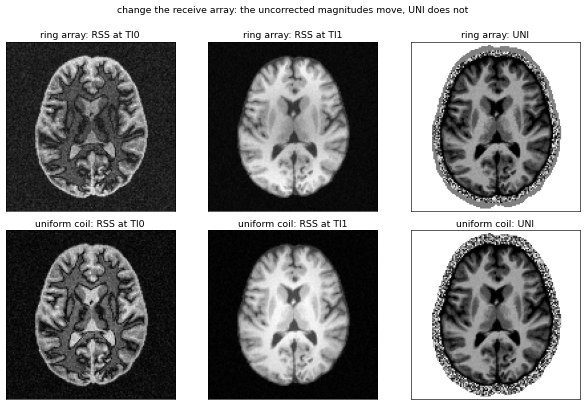

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(11, 7.2))
for row, (label, magnitudes, combined) in enumerate((
        ('ring array', uncorrected, uni), ('uniform coil', flat_rss, flat_uni))):
    for column, contrast in enumerate((0, 1)):
        axes[row, column].imshow(magnitudes[contrast], origin='lower', cmap='gray')
        axes[row, column].set(title=f'{label}: RSS at TI{contrast}', xticks=[], yticks=[])
    axes[row, 2].imshow(np.where(mask, combined, np.nan), origin='lower', cmap='gray',
                        vmin=-0.5, vmax=0.5)
    axes[row, 2].set(title=f'{label}: UNI', xticks=[], yticks=[])
fig.suptitle('change the receive array: the uncorrected magnitudes move, UNI does not', y=1.0)
fig.tight_layout()

---
## 5. The background, and a term this pipeline turns out not to need

`UNI` is bounded on $[-0.5, 0.5]$ **everywhere**, including where there is no object, and that is
ordinarily a problem rather than a feature. Outside the head both images are pure noise, so the
ratio is one of two independent complex Gaussians — nothing makes it small. Summing over eight
coils does average it down, but only to about half the level of the tissue, and what is left is
structureless: the classic MP2RAGE symptom is a loud, grainy rim around the head. The classic fix
adds a constant to the denominator only:

$$\mathrm{UNI}_\beta = \frac{\mathrm{Re}(S_1 S_2^{*})}{|S_1|^2 + |S_2|^2 + 2\beta}$$

Where the signal is strong $2\beta$ is negligible; where it is noise, $2\beta$ dominates and the
whole expression collapses towards zero.

**It does not arise here, and the reason is the reconstruction.** ESPIRiT estimates sensitivities
only over the object's support and returns exactly zero outside it, so `SenseRecon`'s forward
model has nothing to explain there and its solution is exactly zero too. The comparison worth
making is therefore against the combination that needs no maps — the per-coil form, which is
exact algebra and defined everywhere:

```python
UNI = sum_c Re(S1c · conj(S2c)) / sum_c (|S1c|² + |S2c|²)
```

Same data, two combinations, and only one of them has a background.

In [7]:
def per_coil_uni(coil_images, beta=0.0):
    """UNI without a sensitivity estimate: sum numerator and denominator over coils, then divide.

    Exact, because |C_c|^2 is a common factor of both sums and divides out -- see section 3's
    algebra.  It needs no maps, which also means it has no notion of where the object is.
    """
    top = np.real(coil_images[0] * np.conj(coil_images[1])).sum(0)
    bottom = (np.abs(coil_images[0]) ** 2 + np.abs(coil_images[1]) ** 2).sum(0)
    return top / np.maximum(bottom + 2 * beta, 1e-30)


coil_images = ifft2c(ksp)
support = np.abs(mps).sum(0) > 0
outside = ~brain & ~support

bare = per_coil_uni(coil_images)
print(f'{"":34s} {"background mean |UNI|":>22s} {"inside the object":>18s}')
print(f'{"per-coil, no maps":34s} {np.abs(bare[outside]).mean():22.4f} '
      f'{np.abs(bare[brain]).mean():18.4f}')
print(f'{"SENSE, ESPIRiT maps":34s} {np.abs(uni[outside]).mean():22.4f} '
      f'{np.abs(uni[brain]).mean():18.4f}')
print()
print(f'the ESPIRiT maps are non-zero over {100 * support.mean():.0f} % of the grid, and the SENSE')
print(f'images are identically zero outside that: max |m| = {np.abs(images[:, ~support]).max():.3g}')

                                    background mean |UNI|  inside the object
per-coil, no maps                                  0.0988             0.1882
SENSE, ESPIRiT maps                                0.0000             0.2080

the ESPIRiT maps are non-zero over 52 % of the grid, and the SENSE
images are identically zero outside that: max |m| = 0


 beta / median denominator   background     object
                    0.00%       0.0988     0.1882
                    0.25%       0.0819     0.1830
                    1.00%       0.0545     0.1728
                    4.00%       0.0236     0.1529
                   16.00%       0.0073     0.1169


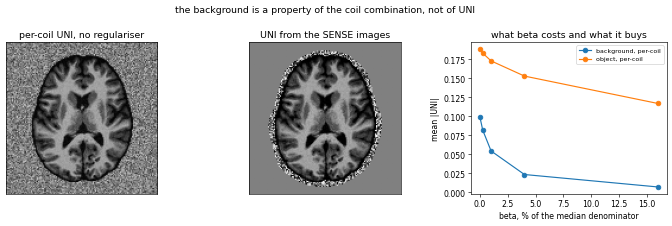

In [8]:
denominator = (np.abs(images[0]) ** 2 + np.abs(images[1]) ** 2)
reference = float(np.median(denominator[brain]))

fig, axes = plt.subplots(1, 3, figsize=(12.5, 4.0))
axes[0].imshow(bare, origin='lower', cmap='gray', vmin=-0.5, vmax=0.5)
axes[0].set(title='per-coil UNI, no regulariser', xticks=[], yticks=[])
axes[1].imshow(uni, origin='lower', cmap='gray', vmin=-0.5, vmax=0.5)
axes[1].set(title='UNI from the SENSE images', xticks=[], yticks=[])

fractions = np.array([0.0, 0.0025, 0.01, 0.04, 0.16])
axes[2].plot(fractions * 100,
             [np.abs(per_coil_uni(coil_images, f * reference)[outside]).mean()
              for f in fractions], 'o-', label='background, per-coil')
axes[2].plot(fractions * 100,
             [np.abs(per_coil_uni(coil_images, f * reference)[brain]).mean()
              for f in fractions], 'o-', label='object, per-coil')
axes[2].set(xlabel='beta, % of the median denominator', ylabel='mean |UNI|',
            title='what beta costs and what it buys')
axes[2].legend(fontsize=8)
fig.suptitle('the background is a property of the coil combination, not of UNI', y=1.0)
fig.tight_layout()

print(f'{"beta / median denominator":>26s} {"background":>12s} {"object":>10s}')
for fraction in fractions:
    combined = per_coil_uni(coil_images, fraction * reference)
    print(f'{fraction:25.2%} {np.abs(combined[outside]).mean():12.4f} '
          f'{np.abs(combined[brain]).mean():10.4f}')

**`beta` is not free, which is the other half of the answer.** It sits in the denominator, so it
pulls *every* voxel towards zero — including the low-signal ones inside the object, and those are
not background. Near the crossing where $|S_1| \approx |S_2|$ and both are small, the denominator
is three orders of magnitude below the median, so a `beta` large enough to flatten the background
flattens that tissue too. The table above is that trade, measured.

So this notebook keeps the SENSE combination with **no** regulariser: the background is already
exactly zero, for a reason that is a property of the reconstruction rather than a parameter. A
pipeline that combines coils by root-sum-of-squares or by an adaptive combine has no object
support to inherit, and `beta` is then the right tool — with the cost above accepted knowingly.

## 6. Is it a T1 map?

`UNI` has to be **monotonic in T1** to be usable as a lookup, and it is — over a window rather
than everywhere. What bounds the window is not either null point but the two T1s at which
$|S_1| = |S_2|$: there $\mathrm{Re}(S_1S_2^*) = \mp\tfrac12(|S_1|^2+|S_2|^2)$, so `UNI` reaches
$\mp 0.5$ and turns back. Outside that window two different T1s give the same value.

This is a property of MP2RAGE and of the pair of TIs chosen, not a fault in the sequence, and it
is why the analytic lookup is always quoted with a validity range. Widening the window means a
longer second TI, which means a longer shot interval and a longer scan — the efficiency trade
this example deliberately does not chase.

The measurement below finds the window rather than predicting it: the longest decreasing run of
the median-per-T1-bin curve, from the short-T1 end.

`UNI` is not linear in T1 and is not meant to be. The analytic lookup depends on the flip
angles, the TR and the train length as well, and inverting it is analysis rather than sequence.

median UNI over 22 T1 bins, 0.85 .. 2.95 s
minimum -0.321 at T1 = 2.75 s   <- where |S1| = |S2|
below it:  rank correlation with T1 = -0.615   (-1 is perfectly monotone decreasing)
above it:  rank correlation with T1 = +1.000   (the fold: the sign reverses)

The turn is at neither null (1.01 s and 3.17 s), because what bounds the window is |S1| = |S2| rather than
either image reaching zero.  White and grey matter sit inside it here; CSF at 4.2 s does
not, which is the usual MP2RAGE situation and the reason the lookup carries a range.


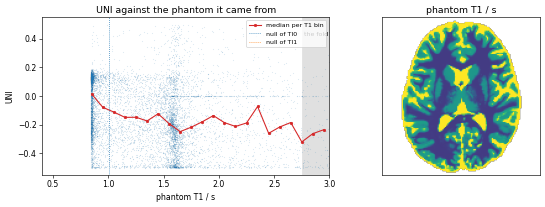

In [9]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
ax[0].plot(t1_map[mask].ravel(), uni[mask].ravel(), '.', ms=1.0, alpha=0.15)
edges = np.linspace(0.4, 3.0, 27)
centres = 0.5 * (edges[:-1] + edges[1:])
binned = np.array([
    np.median(uni[mask][(t1_map[mask] >= lo) & (t1_map[mask] < hi)])
    if ((t1_map[mask] >= lo) & (t1_map[mask] < hi)).sum() > 20 else np.nan
    for lo, hi in zip(edges[:-1], edges[1:])
])
ax[0].plot(centres, binned, 'C3.-', lw=1.4, label='median per T1 bin')
for contrast, ti in enumerate(TI_S):
    ax[0].axvline(ti / np.log(2), color=f'C{contrast}', ls=':', lw=1.0,
                  label=f'null of TI{contrast}')
ax[0].axvspan(centres[int(np.nanargmin(binned))], 3.0, color='0.88', zorder=0)
ax[0].text(0.5 * (centres[int(np.nanargmin(binned))] + 3.0), 0.42, 'the fold', ha='center',
           fontsize=8)

ax[0].set(xlabel='phantom T1 / s', ylabel='UNI', xlim=(0.4, 3.0), ylim=(-0.55, 0.55),
          title='UNI against the phantom it came from')
ax[0].legend(fontsize=8)

ax[1].imshow(np.where(mask, t1_map, np.nan), origin='lower', cmap='viridis', vmin=0.5, vmax=2.5)
ax[1].set(title='phantom T1 / s', xticks=[], yticks=[])
fig.tight_layout()

usable = ~np.isnan(binned)
curve, axis = binned[usable], centres[usable]

# Where the mapping turns is a measurement rather than a prediction: the minimum of the
# median-per-bin curve.  Below it, monotonicity is reported as a rank correlation, which is what
# a lookup actually needs -- a few dozen voxels per bin make a strict step-by-step test noisy
# without saying anything about whether the mapping is single-valued.
turn = int(np.argmin(curve))


def rank_correlation(a, b):
    """Spearman: Pearson on the ranks, which is monotonicity without assuming a shape."""
    ranks = [np.argsort(np.argsort(v)).astype(float) for v in (a, b)]
    centred = [r - r.mean() for r in ranks]
    return float(centred[0] @ centred[1]
                 / np.sqrt((centred[0] ** 2).sum() * (centred[1] ** 2).sum()))


print(f'median UNI over {len(curve)} T1 bins, {axis[0]:.2f} .. {axis[-1]:.2f} s')
print(f'minimum {curve[turn]:+.3f} at T1 = {axis[turn]:.2f} s   <- where |S1| = |S2|')
print(f'below it:  rank correlation with T1 = '
      f'{rank_correlation(axis[:turn + 1], curve[:turn + 1]):+.3f}   '
      f'(-1 is perfectly monotone decreasing)')
if turn + 1 < len(curve):
    print(f'above it:  rank correlation with T1 = '
          f'{rank_correlation(axis[turn:], curve[turn:]):+.3f}   '
          f'(the fold: the sign reverses)')
print()
print(f'The turn is at neither null ({TI_S[0] / np.log(2):.2f} s and '
      f'{TI_S[1] / np.log(2):.2f} s), because what bounds the window is |S1| = |S2| rather than')
print('either image reaching zero.  White and grey matter sit inside it here; CSF at 4.2 s does')
print('not, which is the usual MP2RAGE situation and the reason the lookup carries a range.')

---
## What this notebook established

| | |
|---|---|
| the two contrasts come out of **one file**, split by `SET` read back from it | and each half is a complete k-space, which is the assertion that a stateful-label bug would fail |
| the receive field cancels **per coil, before any combination** | $\|C_c\|^2$ divides out of $\mathrm{Re}(S_1S_2^*)/(\|S_1\|^2+\|S_2\|^2)$, so no sensitivity estimate is needed and none can be wrong |
| `UNI` is bounded on $[-0.5, 0.5]$ | not a convention: $\|\mathrm{Re}(ab^*)\| \le (\|a\|^2+\|b\|^2)/2$ |
| **a ratio of noise is not small** | the per-coil combination has a background spread over `UNI`'s full range; the SENSE one has none at all, because ESPIRiT's maps vanish outside the object and `SenseRecon` returns exactly zero there |
| the usual $2\beta$ regulariser is therefore **not used** | it would work, and it is not free: it pulls low-signal tissue towards zero along with the background, which near $\|S_1\|=\|S_2\|$ is real contrast |
| one **ESPIRiT map set** for both contrasts | the maps carry an arbitrary common phase, which cancels in $\mathrm{Re}(\hat m_1\hat m_2^*)$ only if both reconstructions used the same one |
| **the same file against two different arrays** moves the magnitudes and leaves `UNI` unchanged | a stronger statement than any single picture, because it holds the anatomy fixed and changes only the thing being cancelled |
| `UNI` is monotonic over a **window bounded by where** $\|S_1\| = \|S_2\|$, and folds beyond it | not at either null point, and measured rather than predicted; white and grey matter sit inside it, CSF does not |

What is **not** here, on purpose: T1 fitting from `UNI`, and any 3D variant. The first is
analysis rather than sequence; the second waits for `GRE3D`, which is where the ky–kz sampling
question has to be answered rather than deferred.